# How small can a network be and still evaluate chess?

Six architectures spanning three orders of magnitude, from a 385-parameter
linear model to a ~270K-parameter NNUE, trained on the same positions and
judged on three axes: accuracy, size, and **latency**.

The latency axis is the one that usually decides the argument. A search
evaluates hundreds of thousands of leaves per move and the hand-written
evaluation costs about six microseconds. A network that is more accurate but
takes fifty is not an improvement — it is a smaller search wearing a better
evaluation, and the smaller search usually wins the game.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "figure.figsize": (9, 4.5), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

## The training set

Labelled by distillation: the engine's own evaluation, after a quiescence
search settles the position. Labelling the raw static score would teach the
network the engine's blind spots mid-exchange.

Labels are clamped to ±1500cp. Self-play with random exploration produces
plenty of positions where one side is a queen and a rook up; left alone those
saturate `tanh` completely and the network spends its capacity on games that
are already over.

5878 positions from 80 games in 21s
label spread: std 773 cp, mean |cp| 573


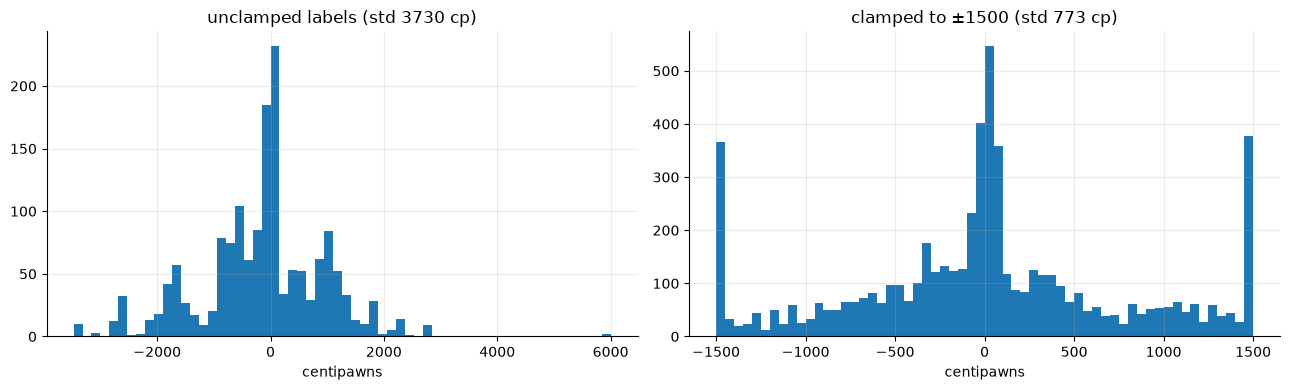

In [2]:
from research.minimal_nnue.dataset import build_dataset

dataset = build_dataset(games=80, max_plies=140, seed=7)
print(f"{len(dataset)} positions from 80 games in {dataset.seconds:.0f}s")
print(f"label spread: std {dataset.centipawns.std():.0f} cp, mean |cp| {abs(dataset.centipawns).mean():.0f}")

unclamped = build_dataset(games=20, max_plies=140, seed=7, clip_cp=1e9)
fig, (left, right) = plt.subplots(1, 2, figsize=(13, 4))
left.hist(np.clip(unclamped.centipawns, -6000, 6000), bins=60)
left.set_title(f"unclamped labels (std {unclamped.centipawns.std():.0f} cp)")
left.set_xlabel("centipawns")
right.hist(dataset.centipawns, bins=60)
right.set_title(f"clamped to ±1500 (std {dataset.centipawns.std():.0f} cp)")
right.set_xlabel("centipawns")
plt.tight_layout(); plt.show()

## The six architectures

In [3]:
from research.minimal_nnue.architecture_search import ARCHITECTURES, run_architecture_search

for architecture in ARCHITECTURES:
    print(f"{architecture.name:<16} {architecture.describe()}")

linear-folded    384 → 1 (385 params)
linear-planes    768 → 1 (769 params)
mlp-16           768 → 16 → 1 (12,321 params)
mlp-32x32        768 → 32 → 32 → 1 (25,697 params)
mlp-128          768 → 128 → 1 (98,561 params)
nnue-336x32      768 → 336 → 32 → 1 (269,201 params)


In [4]:
report = run_architecture_search(dataset, epochs=60,
    on_result=lambda r: print(f"  {r.architecture.name:<16} {r.seconds:5.1f}s"))
print()
print(report.table())

  linear-folded      0.9s


  linear-planes      0.4s


  mlp-16             0.7s


  mlp-32x32          0.8s


  mlp-128            1.1s


  nnue-336x32        1.8s

architecture        params   val MSE   MAE cp  vs mean  1-pos µs  batch µs
--------------------------------------------------------------------------
linear-folded          385    0.0916    357.7    585.3       5.1      0.02
linear-planes          769    0.0902    358.9    585.3       5.1      0.02
mlp-16              12,321    0.0394    216.0    585.3      10.5      0.19
mlp-32x32           25,697    0.0353    180.9    585.3      16.6      0.35
mlp-128             98,561    0.0299    160.3    585.3      13.1      0.26
nnue-336x32        269,201    0.0304    185.3    585.3      22.6      0.78


## Accuracy against cost

The dashed line is the hand-written evaluation this would have to replace.

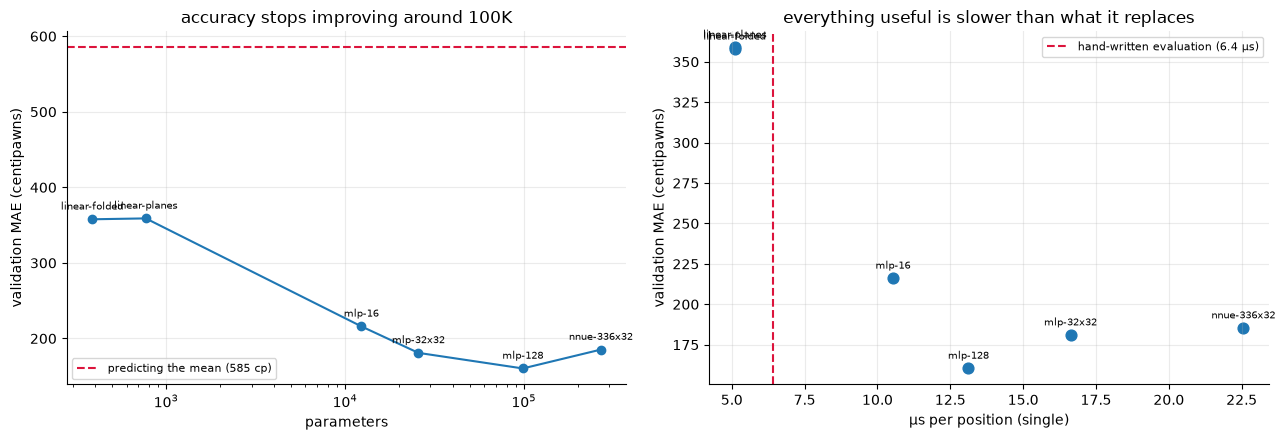

In [5]:
import chess, timeit
from engine.evaluation.tapered import positional_eval
board = chess.Board("r1bq1rk1/pp2ppbp/2np1np1/8/2BNP3/2N1BP2/PPPQ2PP/R3K2R w KQ - 0 9")
classical_us = timeit.timeit(lambda: positional_eval(board), number=20000) / 20000 * 1e6

params = [r.parameters for r in report.reports]
mae = [r.val_mae_cp for r in report.reports]
latency = [r.latency_us for r in report.reports]
labels = [r.architecture.name for r in report.reports]
baseline = report.reports[0].baseline_mae_cp

fig, (left, right) = plt.subplots(1, 2, figsize=(13, 4.5))
left.semilogx(params, mae, marker="o")
left.axhline(baseline, color="crimson", ls="--", label=f"predicting the mean ({baseline:.0f} cp)")
for x, y, label in zip(params, mae, labels):
    left.annotate(label, (x, y), fontsize=7, xytext=(0, 7), textcoords="offset points", ha="center")
left.set_xlabel("parameters"); left.set_ylabel("validation MAE (centipawns)")
left.set_title("accuracy stops improving around 100K"); left.legend(fontsize=8)

right.scatter(latency, mae, s=60)
right.axvline(classical_us, color="crimson", ls="--",
              label=f"hand-written evaluation ({classical_us:.1f} µs)")
for x, y, label in zip(latency, mae, labels):
    right.annotate(label, (x, y), fontsize=7, xytext=(0, 7), textcoords="offset points", ha="center")
right.set_xlabel("µs per position (single)"); right.set_ylabel("validation MAE (centipawns)")
right.set_title("everything useful is slower than what it replaces"); right.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Input-feature ablation

Network held fixed at 768→32→32→1; only what it is shown changes.

architecture        params   val MSE   MAE cp  vs mean  1-pos µs  batch µs
--------------------------------------------------------------------------
folded              13,409    0.0344    157.7    585.3      16.4      0.31
planes              25,697    0.0353    180.9    585.3      17.7      0.38
planes+phase        25,729    0.0355    184.5    585.3      20.2      0.34
planes+handcrafted    25,953    0.0348    187.7    585.3      18.2      0.38


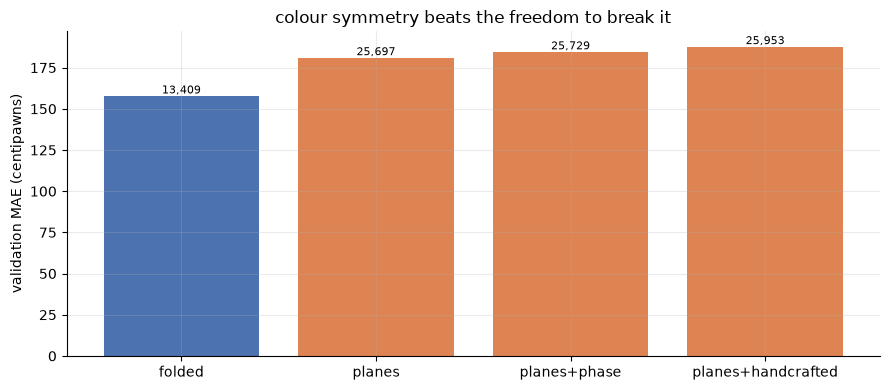

In [6]:
from research.minimal_nnue.architecture_search import run_feature_ablation

ablation = run_feature_ablation(dataset, epochs=60)
print(ablation.table())

names = [r.architecture.name for r in ablation.reports]
values = [r.val_mae_cp for r in ablation.reports]
sizes = [r.parameters for r in ablation.reports]

fig, axis = plt.subplots(figsize=(9, 4))
bars = axis.bar(names, values, color=["#4c72b0", "#dd8452", "#dd8452", "#dd8452"])
for bar, size in zip(bars, sizes):
    axis.annotate(f"{size:,}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                  ha="center", va="bottom", fontsize=8)
axis.set_ylabel("validation MAE (centipawns)")
axis.set_title("colour symmetry beats the freedom to break it")
plt.tight_layout(); plt.show()

## Three findings

**1. The latency column decides it.** Every network that meaningfully beats the
linear baseline costs two to four times the entire evaluation it would replace.
At this scale, in this language, an NNUE cannot pay for itself inside the
search. The batch column shows this is a Python problem and not a network one:
amortised over a batch the same forward pass is twenty to forty times cheaper.

**2. The linear models are the only free ones.** A linear model over
piece-square features *is* a piece-square table — it folds into the lookup the
engine already walks. It is also barely better than predicting the mean, which
is the real answer to "how small can this be": small enough to be free, and
then not worth having.

**3. Colour symmetry is a better prior than the freedom to break it.** The
folded 384-wide encoding beats the 768-wide one with half the parameters.
Adding phase or handcrafted terms made it slightly worse — both are functions
of the board the network can already see.